# PHY 657 Problem Set 3: Regression & Matched Filtering
**Spring 2026** Belal Menbari

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import rfft, fft, ifft, fftfreq, rfftfreq
from scipy.optimize import curve_fit, brentq
from scipy.stats import norm
%matplotlib inline
plt.rcParams.update({'font.size': 12, 'figure.figsize': (8, 4)})

---
## Problem 1: Likelihood and Parameter Uncertainty

Detector triggers with probability theta per trial. N trials, k triggers.

### (a) Maximum Likelihood Estimate

Likelihood is binomial:

$$p(k|\theta) = \binom{N}{k}\theta^{k}(1-\theta)^{N-k}$$

Log-likelihood (drop the $\binom{N}{k}$ since it doesn't depend on $\theta$):

$$\ln L = k\ln\theta + (N-k)\ln(1-\theta)$$

Set derivative to zero:

$$\frac{d\ln L}{d\theta} = \frac{k}{\theta} - \frac{N-k}{1-\theta} = 0$$

Multiply both sides by $\theta(1-\theta)$:

$$k(1-\theta) = (N-k)\theta \implies k = N\theta$$

$$\boxed{\hat\theta_{\rm MLE} = \frac{k}{N}}$$

Just the observed fraction of successes.

### (b) Numerical Log-Likelihood Scan (N=40, k=26)

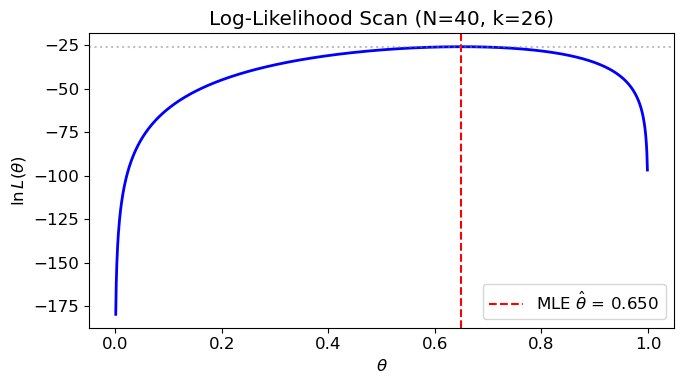

MLE: theta_hat = 0.6500


In [35]:
N_trials, k_obs = 40, 26
theta_arr = np.linspace(0.001, 0.999, 2000)

logL = k_obs * np.log(theta_arr) + (N_trials - k_obs) * np.log(1 - theta_arr)
theta_mle = k_obs / N_trials
logL_max = k_obs * np.log(theta_mle) + (N_trials - k_obs) * np.log(1 - theta_mle)

plt.figure(figsize=(7, 4))
plt.plot(theta_arr, logL, 'b-', lw=2)
plt.axvline(theta_mle, color='r', ls='--', lw=1.5, label=rf'MLE $\hat\theta$ = {theta_mle:.3f}')
plt.axhline(logL_max, color='gray', ls=':', alpha=0.5)
plt.xlabel(r'$\theta$'); plt.ylabel(r'$\ln L(\theta)$')
plt.title('Log-Likelihood Scan (N=40, k=26)')
plt.legend(); plt.tight_layout(); plt.show()
print(f'MLE: theta_hat = {theta_mle:.4f}')

### (c) 1-sigma Confidence Interval

The 1-sigma bounds are where log-likelihood drops by 1/2 from the peak:

$$\ln L(\theta) = \ln L_{\max} - \frac{1}{2}$$

We solve this numerically on each side.

1-sigma interval: [0.5726, 0.7225]
theta_hat = 0.650  +0.072  / -0.077


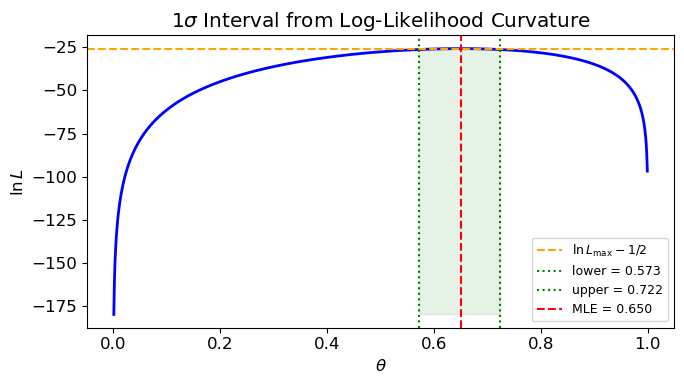

In [36]:
def logL_func(th):
    return k_obs * np.log(th) + (N_trials - k_obs) * np.log(1 - th)

def delta(th):
    return logL_func(th) - logL_max + 0.5

theta_lo = brentq(delta, 0.001, theta_mle)
theta_hi = brentq(delta, theta_mle, 0.999)

print(f'1-sigma interval: [{theta_lo:.4f}, {theta_hi:.4f}]')
print(f'theta_hat = {theta_mle:.3f}  +{theta_hi - theta_mle:.3f}  / -{theta_mle - theta_lo:.3f}')

plt.figure(figsize=(7, 4))
plt.plot(theta_arr, logL, 'b-', lw=2)
plt.axhline(logL_max - 0.5, color='orange', ls='--', label=r'$\ln L_{\max} - 1/2$')
plt.axvline(theta_lo, color='green', ls=':', lw=1.5, label=f'lower = {theta_lo:.3f}')
plt.axvline(theta_hi, color='green', ls=':', lw=1.5, label=f'upper = {theta_hi:.3f}')
plt.axvline(theta_mle, color='r', ls='--', lw=1.5, label=f'MLE = {theta_mle:.3f}')
plt.fill_betweenx([logL.min(), logL_max], theta_lo, theta_hi, alpha=0.1, color='green')
plt.xlabel(r'$\theta$'); plt.ylabel(r'$\ln L$')
plt.title(r'$1\sigma$ Interval from Log-Likelihood Curvature')
plt.legend(fontsize=9); plt.tight_layout(); plt.show()

### (d) Interpretation

The width of the likelihood peak tells us how picky the data are about theta. A sharp narrow peak means only a tight range of theta values could plausibly produce our data, so we're very certain. A broad peak means many values work, so we're less certain. The curvature (second derivative) of ln L at the peak is the Fisher information, which sets the precision. More data makes the peak sharper and the uncertainty smaller.

---
## Problem 2: Why Noise Weighting Matters

Model: y = ax + b, each point has its own uncertainty sigma_i.

In [37]:
data_csv = np.genfromtxt('weighted_regression_dataset.csv', delimiter=',', skip_header=1)
x_d, y_d, sig_d = data_csv[:, 0], data_csv[:, 1], data_csv[:, 2]
print(f'{len(x_d)} points, sigma range: [{sig_d.min():.3f}, {sig_d.max():.3f}]')

40 points, sigma range: [0.200, 1.700]


### (a) Unweighted (OLS) Fit

Minimize $\sum_i (y_i - ax_i - b)^2$, ignoring error bars.

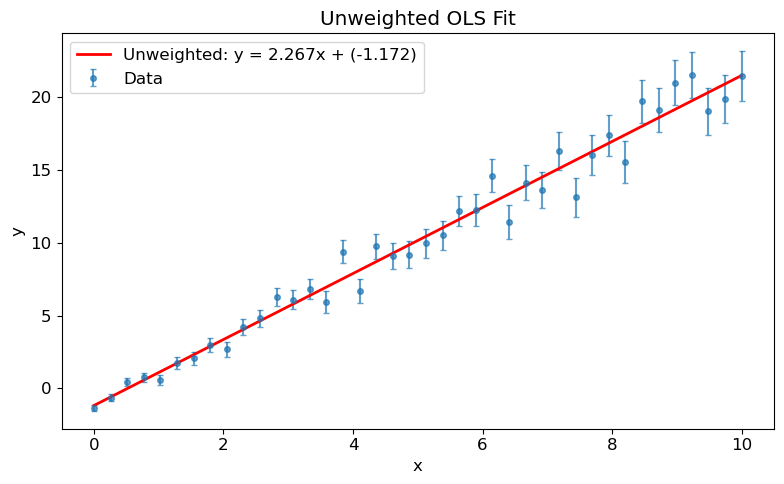

Unweighted: a = 2.2666, b = -1.1715


In [38]:
def line(x, a, b):
    return a * x + b

popt_uw, _ = curve_fit(line, x_d, y_d)
a_uw, b_uw = popt_uw
xf = np.linspace(x_d.min(), x_d.max(), 200)

plt.figure(figsize=(8, 5))
plt.errorbar(x_d, y_d, yerr=sig_d, fmt='o', ms=4, capsize=2, alpha=0.7, label='Data')
plt.plot(xf, line(xf, *popt_uw), 'r-', lw=2, label=f'Unweighted: y = {a_uw:.3f}x + ({b_uw:.3f})')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Unweighted OLS Fit')
plt.legend(); plt.tight_layout(); plt.show()
print(f'Unweighted: a = {a_uw:.4f}, b = {b_uw:.4f}')

### (b) Weighted Fit

Minimize chi-squared:

$$\chi^2 = \sum_i \frac{(y_i - ax_i - b)^2}{\sigma_i^2}$$

Points with small sigma_i get more weight.

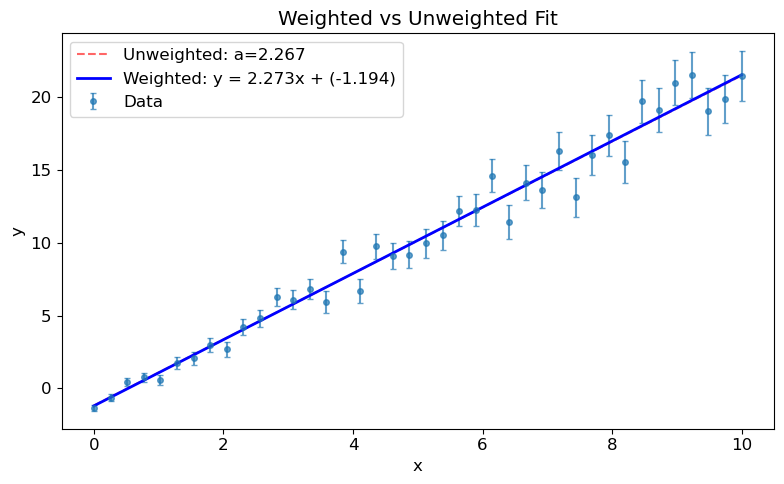

Weighted: a = 2.2730, b = -1.1938


In [39]:
popt_w, _ = curve_fit(line, x_d, y_d, sigma=sig_d, absolute_sigma=True)
a_w, b_w = popt_w

plt.figure(figsize=(8, 5))
plt.errorbar(x_d, y_d, yerr=sig_d, fmt='o', ms=4, capsize=2, alpha=0.7, label='Data')
plt.plot(xf, line(xf, *popt_uw), 'r--', lw=1.5, alpha=0.6, label=f'Unweighted: a={a_uw:.3f}')
plt.plot(xf, line(xf, *popt_w), 'b-', lw=2, label=f'Weighted: y = {a_w:.3f}x + ({b_w:.3f})')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Weighted vs Unweighted Fit')
plt.legend(); plt.tight_layout(); plt.show()
print(f'Weighted: a = {a_w:.4f}, b = {b_w:.4f}')

### (c) Comparison

**1. Which points influenced the weighted fit more?**

The left side points (small x) have the smallest sigma_i, so they get the biggest weights. The weighted line hugs those precise low-x points more tightly.

**2. Why does inverse-variance weighting improve parameter estimation?**

A point with small sigma_i is reliable and tightly constrains the line. A noisy point could be far off by chance. Weighting by $1/\sigma_i^2$ gives each point influence proportional to its information content. This is what maximizing the Gaussian likelihood gives, so it's statistically optimal.

### (d) Conceptual Connection to Matched Filtering

If we have a known template $\mathbf{s}$ in noise with covariance $\Sigma$, we're fitting $\mathbf{d} = A\mathbf{s} + \mathbf{n}$. The Gaussian log-likelihood:

$$\ln L \propto -(\mathbf{d} - A\mathbf{s})^T \Sigma^{-1} (\mathbf{d} - A\mathbf{s})$$

This is the multi-dimensional chi-squared, with $\Sigma^{-1}$ playing the role of $1/\sigma_i^2$. The inverse covariance downweights noisy frequencies, just like inverse-variance weighting downweighted noisy points. That's why the optimal estimator (matched filter) weights by $\Sigma^{-1}$.

---
## Problem 3: Matched Filtering, Calibration, and Detection Efficiency

### Helper Functions

In [40]:
def calc_psd(x, fs=1.0, folded_over=True):
    norm_fac = fs * x.shape[-1]
    if folded_over:
        if x.ndim == 1:
            psd = (np.abs(rfft(x))**2.0) / norm_fac
        else:
            psd = np.mean(np.abs(rfft(x))**2.0, axis=0) / norm_fac
        psd[1:x.shape[-1]//2+1 - (x.shape[-1]+1)%2] *= 2.0
        f = rfftfreq(x.shape[-1], d=1.0/fs)
    else:
        if x.ndim == 1:
            psd = (np.abs(fft(x))**2.0) / norm_fac
        else:
            psd = np.mean(np.abs(fft(x))**2.0, axis=0) / norm_fac
        f = fftfreq(x.shape[-1], d=1.0/fs)
    return f, psd

def foldpsd(psd, fs):
    psd_len = psd.shape[-1]
    psd_folded = np.copy(psd[...,:psd_len//2 + 1])
    psd_folded[..., 1:psd_len//2 + (psd_len)%2] *= 2.0
    f = rfftfreq(psd_len, d=1.0/fs)
    return f, psd_folded

def optimal_filter_amp(signal, template, psd, fs, coupling="AC"):
    nbins = signal.size
    df = fs / nbins
    psd_safe = psd.astype(float).copy()
    if coupling == "AC":
        psd_safe[0] = np.inf
    tiny = np.finfo(float).tiny
    psd_safe = np.where(np.isfinite(psd_safe), np.maximum(psd_safe, tiny), psd_safe)
    S = fft(template) / nbins / df
    V = fft(signal) / nbins / df
    phi = np.conjugate(S) / psd_safe
    norm_val = np.real(np.dot(phi, S)) * df
    num = np.sum(phi * V) * df
    amp = np.real(num) / norm_val
    sigma = 1.0 / np.sqrt(norm_val)
    return amp, sigma

In [41]:
def _pick_top_hist_peaks(counts, centers, n):
    sm = np.convolve(counts, np.ones(3)/3, mode='same')
    order = np.argsort(sm)[::-1]
    chosen = []
    min_sep = (centers[1] - centers[0]) * 6.0
    for idx in order:
        c = centers[idx]
        if all(abs(c - cc) > min_sep for cc in chosen):
            chosen.append(c)
        if len(chosen) >= n:
            break
    if len(chosen) < n:
        qs = np.linspace(0.1, 0.9, n)
        chosen = list(np.quantile(centers, qs))
    return np.array(sorted(chosen))

def fit_spectrum_curvefit(amplitudes, n_lines=3, mus_guess=None, sig_guess=None,
                          include_flat=True, bins=120, range_vals=None, verbose=False):
    x = np.asarray(amplitudes).ravel()
    N = x.size
    counts, edges = np.histogram(x, bins=bins, range=range_vals)
    centers = 0.5 * (edges[:-1] + edges[1:])
    bw = edges[1] - edges[0]
    span = edges[-1] - edges[0]
    n_gauss = int(n_lines)
    if mus_guess is None:
        mus_guess = _pick_top_hist_peaks(counts, centers, n_gauss)
    else:
        mus_guess = np.asarray(mus_guess).ravel()
    if sig_guess is None:
        sig_guess = np.full(n_gauss, max(1e-3, 0.03 * span))
    else:
        sig_guess = np.asarray(sig_guess).ravel()
    def _model(xc, *p):
        out = np.zeros_like(xc, dtype=float)
        ptr = 0
        for g in range(n_gauss):
            area, mu, sig = p[ptr], p[ptr+1], max(1e-9, abs(p[ptr+2]))
            ptr += 3
            out += area * norm.pdf(xc, loc=mu, scale=sig) * bw
        if include_flat:
            out += max(0.0, p[ptr])
        return out
    p0 = []
    for i in range(n_gauss):
        idx_c = np.argmin(np.abs(centers - mus_guess[i]))
        est_area = max(counts[idx_c] * sig_guess[i] * np.sqrt(2*np.pi), N/(n_gauss+1)*0.1)
        p0.extend([float(est_area), float(mus_guess[i]), float(sig_guess[i])])
    if include_flat:
        p0.append(float(max(0.0, np.median(counts)*0.2)))
    lo, hi = [], []
    for g in range(n_gauss):
        lo.extend([0.0, edges[0]-0.2*span, 1e-6])
        hi.extend([N*10, edges[-1]+0.2*span, span])
    if include_flat:
        lo.append(0.0); hi.append(N*0.5)
    popt, pcov = curve_fit(_model, centers, counts, p0=p0, bounds=(lo, hi), maxfev=50000)
    ptr = 0
    areas, mus, sigs = [], [], []
    for g in range(n_gauss):
        areas.append(popt[ptr]); mus.append(popt[ptr+1]); sigs.append(abs(popt[ptr+2]))
        ptr += 3
    flatC = float(popt[ptr]) if include_flat else 0.0
    model_counts = _model(centers, *popt)
    result = {"bin_centers": centers, "bin_edges": edges, "counts": counts,
              "areas": np.array(areas), "mus": np.array(mus), "sigs": np.array(sigs),
              "flat_counts_per_bin": flatC, "model_counts": model_counts,
              "popt": popt, "pcov": pcov}
    if verbose:
        print("mus:", result["mus"]); print("sigs:", result["sigs"])
        print("areas:", result["areas"]); print("flat/bin:", flatC)
    return result

In [42]:
fs = 5e3
trace_length = 4096
dt = 1 / fs
time = np.arange(trace_length) * dt

noise_data = np.load(r'C:\Users\belal\Downloads\noise_traces.npy')
pulse_data = np.load(r'C:\Users\belal\Downloads\event_traces.npy')

print(f'Noise: {noise_data.shape}, Pulses: {pulse_data.shape}')

Noise: (300, 4096), Pulses: (3000, 4096)


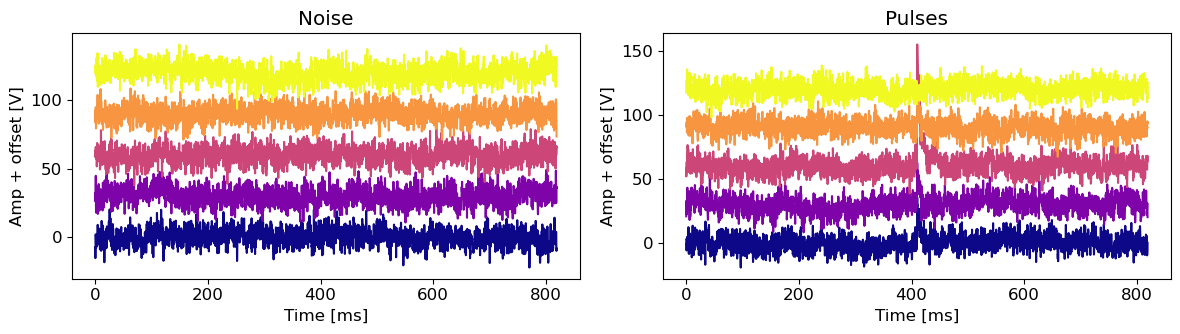

In [43]:
# quick look at traces
colors = plt.get_cmap("plasma")
c = colors(np.linspace(0, 1, 5))
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
for ii in range(5):
    ax[0].plot(time*1e3, noise_data[ii] + ii*30, c=c[ii])
    ax[1].plot(time*1e3, pulse_data[ii] + ii*30, c=c[ii])
ax[0].set_xlabel('Time [ms]'); ax[0].set_ylabel('Amp + offset [V]'); ax[0].set_title('Noise')
ax[1].set_xlabel('Time [ms]'); ax[1].set_ylabel('Amp + offset [V]'); ax[1].set_title('Pulses')
plt.tight_layout(); plt.show()

### Part I: Matched Filter Amplitudes

**Step 1: Noise PSD**

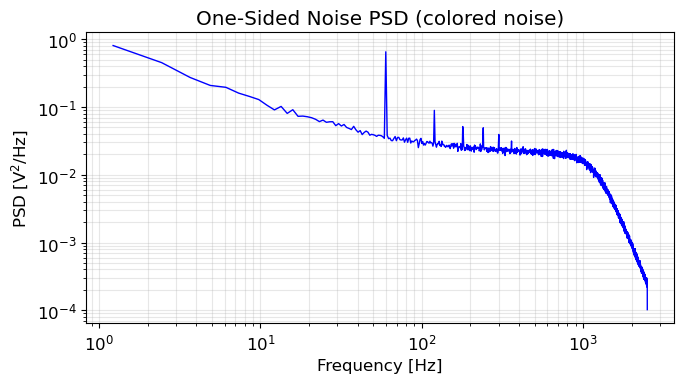

Noise is colored (PSD not flat) => matched filtering matters.


In [44]:
# two-sided PSD for matched filter
_, psd_2sided = calc_psd(noise_data, fs=fs, folded_over=False)

# one-sided for plotting
f_1s, psd_1sided = calc_psd(noise_data, fs=fs, folded_over=True)

plt.figure(figsize=(7, 4))
plt.loglog(f_1s[1:], psd_1sided[1:], 'b-', lw=1)
plt.xlabel('Frequency [Hz]'); plt.ylabel(r'PSD [V$^2$/Hz]')
plt.title('One-Sided Noise PSD (colored noise)')
plt.grid(True, which='both', alpha=0.3); plt.tight_layout(); plt.show()
print("Noise is colored (PSD not flat) => matched filtering matters.")

**Step 2: Pulse template**

$$s(t) \propto e^{-t/\tau_{\rm fall}} - e^{-t/\tau_{\rm rise}}, \quad \tau_{\rm rise}=100\,\mu s,\;\tau_{\rm fall}=5\,\text{ms}$$

Normalized so peak = 1.

C:\Users\belal\AppData\Local\Temp\ipykernel_6456\4099694158.py:5: RuntimeWarning: overflow encountered in exp
  np.exp(-t_centered/tau_fall) - np.exp(-t_centered/tau_rise), 0.0)


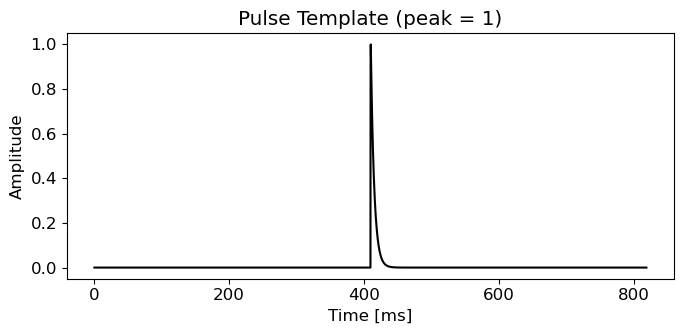

In [45]:
tau_rise = 100e-6
tau_fall = 5e-3
t_centered = time - time[trace_length // 2]
raw_pulse = np.where(t_centered >= 0,
                     np.exp(-t_centered/tau_fall) - np.exp(-t_centered/tau_rise), 0.0)
template = raw_pulse / raw_pulse.max()

plt.figure(figsize=(7, 3.5))
plt.plot(time*1e3, template, 'k-', lw=1.5)
plt.xlabel('Time [ms]'); plt.ylabel('Amplitude')
plt.title('Pulse Template (peak = 1)'); plt.tight_layout(); plt.show()

**Step 3-4: Apply matched filter to all events**

$$a_{\rm MF} = \frac{\sum_k \tilde{s}^*(f_k)\,\tilde{d}(f_k)/J(f_k)}{\sum_k |\tilde{s}(f_k)|^2/J(f_k)}$$

This downweights noisy frequencies, exactly like inverse-variance weighting from Problem 2.

MF resolution (sigma): 2.499
Amplitude range: [-8.0, 106.1]


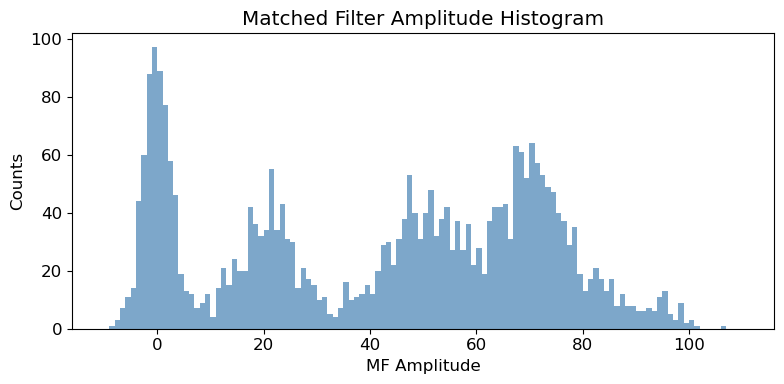

In [46]:
n_events = pulse_data.shape[0]
amps_mf = np.zeros(n_events)
sigma_mf = 0.0

for i in range(n_events):
    a, s = optimal_filter_amp(pulse_data[i], template, psd_2sided, fs)
    amps_mf[i] = a
    if i == 0:
        sigma_mf = s

print(f'MF resolution (sigma): {sigma_mf:.3f}')
print(f'Amplitude range: [{amps_mf.min():.1f}, {amps_mf.max():.1f}]')

plt.figure(figsize=(8, 4))
plt.hist(amps_mf, bins=120, range=(-10, 110), alpha=0.7, color='steelblue')
plt.xlabel('MF Amplitude'); plt.ylabel('Counts')
plt.title('Matched Filter Amplitude Histogram'); plt.tight_layout(); plt.show()

### Part II: Spectral Fit and Peak Extraction

Fit the histogram with 4 Gaussians (3 signal lines + noise blob) + flat background.

In [47]:
res = fit_spectrum_curvefit(amps_mf, n_lines=4,
                           mus_guess=(0, 20, 50, 70),
                           sig_guess=(3, 5, 5, 5),
                           include_flat=True,
                           bins=120, range_vals=(-10, 110),
                           verbose=True)

mus: [-5.88814566e-02  2.08979879e+01  4.97719037e+01  7.05575282e+01]
sigs: [2.49299038 5.09570072 6.33189646 6.49731526]
areas: [574.33124876 457.16564276 587.99278933 842.58136329]
flat/bin: 4.48288405669153


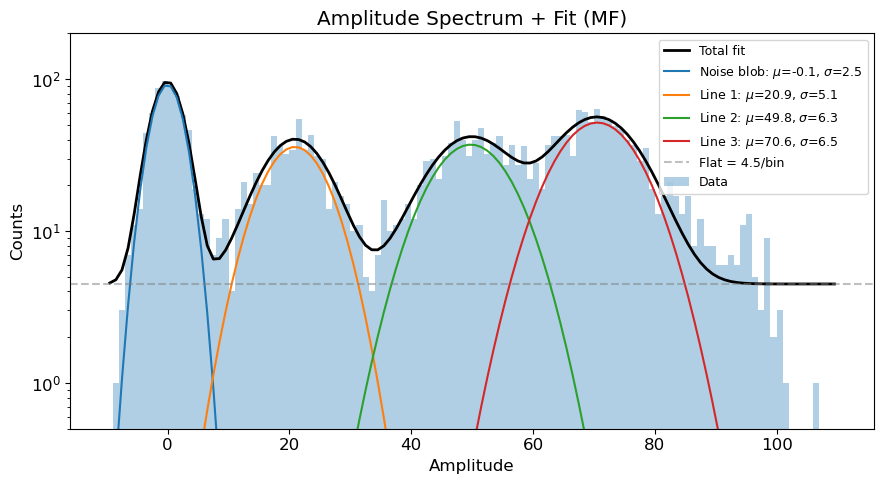


Fitted peaks:
  Noise blob: mu = -0.06, sigma = 2.49
  Line 1: mu = 20.90, sigma = 5.10
  Line 2: mu = 49.77, sigma = 6.33
  Line 3: mu = 70.56, sigma = 6.50


In [48]:
bw = res['bin_edges'][1] - res['bin_edges'][0]

plt.figure(figsize=(9, 5))
plt.bar(res['bin_centers'], res['counts'], width=bw, alpha=0.35, label='Data')
plt.plot(res['bin_centers'], res['model_counts'], 'k-', lw=2, label='Total fit')

labels = ['Noise blob', 'Line 1', 'Line 2', 'Line 3']
for i in range(4):
    comp = res['areas'][i] * norm.pdf(res['bin_centers'], loc=res['mus'][i],
                                       scale=res['sigs'][i]) * bw
    plt.plot(res['bin_centers'], comp, lw=1.5,
             label=f"{labels[i]}: $\mu$={res['mus'][i]:.1f}, $\sigma$={res['sigs'][i]:.1f}")

plt.axhline(res['flat_counts_per_bin'], color='gray', ls='--', alpha=0.5,
            label=f"Flat = {res['flat_counts_per_bin']:.1f}/bin")
plt.xlabel('Amplitude'); plt.ylabel('Counts')
plt.title('Amplitude Spectrum + Fit (MF)')
plt.yscale('log'); plt.ylim(0.5, 200)
plt.legend(fontsize=9); plt.tight_layout(); plt.show()

print("\nFitted peaks:")
for i, lab in enumerate(labels):
    print(f"  {lab}: mu = {res['mus'][i]:.2f}, sigma = {res['sigs'][i]:.2f}")

**Diagnostic: NLL scan around mu_1**

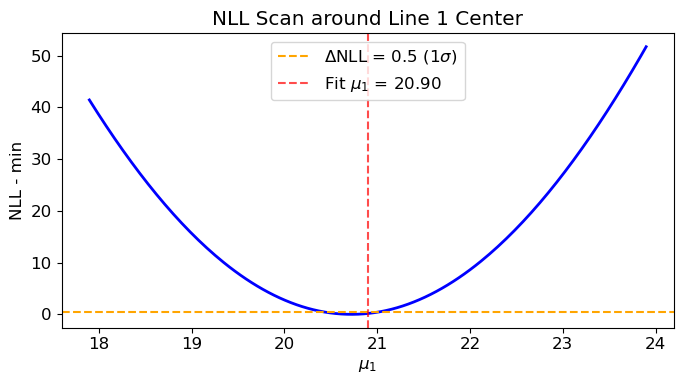

Sharp minimum = line position is well-determined.


In [49]:
mu1_fit = res['mus'][1]
mu1_scan = np.linspace(mu1_fit - 3, mu1_fit + 3, 200)
centers = res['bin_centers']
counts = res['counts']
bw = res['bin_edges'][1] - res['bin_edges'][0]

def model_scan(mu1_val):
    out = np.zeros_like(centers)
    for i in range(4):
        mu_i = mu1_val if i == 1 else res['mus'][i]
        out += res['areas'][i] * norm.pdf(centers, loc=mu_i, scale=res['sigs'][i]) * bw
    out += res['flat_counts_per_bin']
    return out

nll = np.zeros_like(mu1_scan)
for j, m in enumerate(mu1_scan):
    lam = np.maximum(model_scan(m), 1e-10)
    nll[j] = -np.sum(counts * np.log(lam) - lam)

nll_min = nll.min()
plt.figure(figsize=(7, 4))
plt.plot(mu1_scan, nll - nll_min, 'b-', lw=2)
plt.axhline(0.5, color='orange', ls='--', label=r'$\Delta$NLL = 0.5 (1$\sigma$)')
plt.axvline(mu1_fit, color='r', ls='--', alpha=0.7, label=f'Fit $\mu_1$ = {mu1_fit:.2f}')
plt.xlabel(r'$\mu_1$'); plt.ylabel('NLL - min')
plt.title('NLL Scan around Line 1 Center')
plt.legend(); plt.tight_layout(); plt.show()
print("Sharp minimum = line position is well-determined.")

### Part III: Energy Calibration

True line energies: $E_1=25$ keV, $E_2=65$ keV, $E_3=100$ keV.

Saturation model:

$$E_{\rm recon} = a\left(1 - e^{-E_{\rm true}/b}\right)$$

Fit a and b from the 3 measured line amplitudes.

Measured line amplitudes: [20.89798788 49.77190367 70.55752816]
Calibration: a = 183.02, b = 205.22


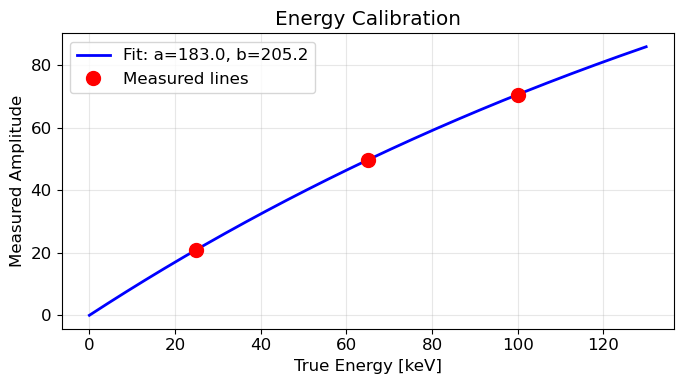

In [50]:
E_true = np.array([25.0, 65.0, 100.0])
line_idx = np.argsort(res['mus'][1:4]) + 1
A_measured = res['mus'][line_idx]
print("Measured line amplitudes:", A_measured)

def saturation(E, a, b):
    return a * (1 - np.exp(-E / b))

popt_cal, _ = curve_fit(saturation, E_true, A_measured, p0=[100, 80])
a_cal, b_cal = popt_cal
print(f'Calibration: a = {a_cal:.2f}, b = {b_cal:.2f}')

E_plot = np.linspace(0, 130, 300)
plt.figure(figsize=(7, 4))
plt.plot(E_plot, saturation(E_plot, a_cal, b_cal), 'b-', lw=2, label=f'Fit: a={a_cal:.1f}, b={b_cal:.1f}')
plt.plot(E_true, A_measured, 'ro', ms=10, zorder=5, label='Measured lines')
plt.xlabel('True Energy [keV]'); plt.ylabel('Measured Amplitude')
plt.title('Energy Calibration'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Inverse calibration** to go from amplitude back to energy:

$$E_{\rm recon} = -b\,\ln\!\left(1 - \frac{A}{a}\right)$$

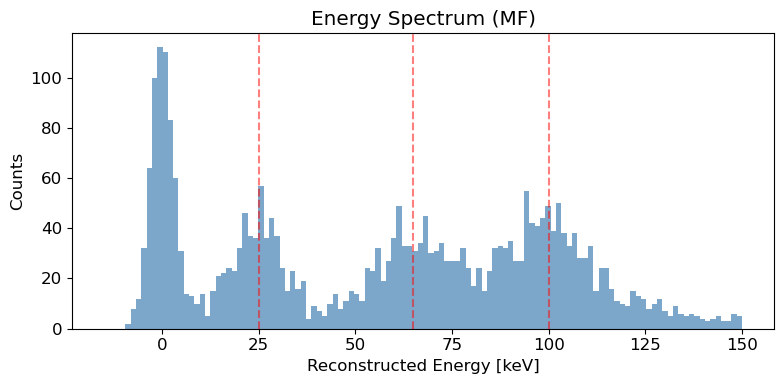

In [51]:
def inverse_cal(A, a, b):
    ratio = np.clip(A / a, -np.inf, 0.9999)
    return -b * np.log(1 - ratio)

E_mf = inverse_cal(amps_mf, a_cal, b_cal)

plt.figure(figsize=(8, 4))
plt.hist(E_mf, bins=120, range=(-15, 150), alpha=0.7, color='steelblue')
for Et in E_true:
    plt.axvline(Et, color='r', ls='--', alpha=0.5)
plt.xlabel('Reconstructed Energy [keV]'); plt.ylabel('Counts')
plt.title('Energy Spectrum (MF)'); plt.tight_layout(); plt.show()

**Why saturation model > polynomial/spline?**

The saturation model has a physical basis (many detectors saturate at high energy). Only 2 parameters, always monotonic, extrapolates sensibly. A polynomial can oscillate and blow up outside the fit range. A spline needs more calibration points and doesn't extrapolate. Physics-based model wins.

### Part IV: Detection Threshold

$$E_{\rm thresh} = \mu_{\rm noise} + 5\sigma_{\rm noise}$$

Noise blob: mu=-0.06, sigma=2.49
Amp threshold: 12.41
Energy threshold: 14.41 keV


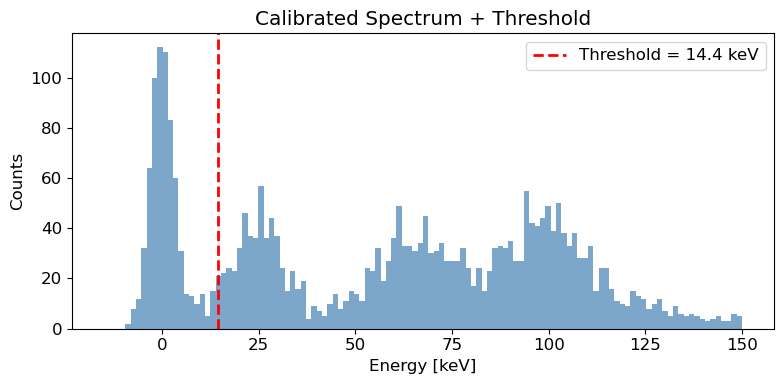

In [52]:
mu_noise = res['mus'][0]
sig_noise = res['sigs'][0]
A_thresh = mu_noise + 5 * sig_noise
E_thresh = inverse_cal(A_thresh, a_cal, b_cal)

print(f'Noise blob: mu={mu_noise:.2f}, sigma={sig_noise:.2f}')
print(f'Amp threshold: {A_thresh:.2f}')
print(f'Energy threshold: {E_thresh:.2f} keV')

plt.figure(figsize=(8, 4))
plt.hist(E_mf, bins=120, range=(-15, 150), alpha=0.7, color='steelblue')
plt.axvline(E_thresh, color='red', lw=2, ls='--', label=f'Threshold = {E_thresh:.1f} keV')
plt.xlabel('Energy [keV]'); plt.ylabel('Counts')
plt.title('Calibrated Spectrum + Threshold')
plt.legend(); plt.tight_layout(); plt.show()

### Part V: Detection Efficiency

Inject fake pulses of known energy into real noise, run through full chain, count what passes threshold.

$$\varepsilon(E) = \frac{N_{\rm detected}(E)}{N_{\rm injected}(E)}$$

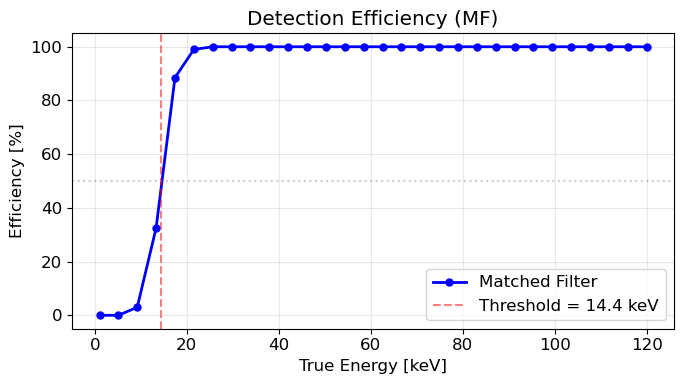

In [53]:
E_inject = np.linspace(1, 120, 30)
n_inject_per = 200
efficiency_mf = np.zeros(len(E_inject))
pulse_start = trace_length // 2
rng = np.random.default_rng(123)

for ie, E in enumerate(E_inject):
    A_true = saturation(E, a_cal, b_cal)
    n_det = 0
    for _ in range(n_inject_per):
        noise_trace = noise_data[rng.integers(0, noise_data.shape[0])]
        fake = A_true * template + noise_trace
        a_est, _ = optimal_filter_amp(fake, template, psd_2sided, fs)
        E_est = inverse_cal(a_est, a_cal, b_cal)
        if E_est > E_thresh:
            n_det += 1
    efficiency_mf[ie] = n_det / n_inject_per

plt.figure(figsize=(7, 4))
plt.plot(E_inject, efficiency_mf * 100, 'bo-', lw=2, ms=5, label='Matched Filter')
plt.axvline(E_thresh, color='r', ls='--', alpha=0.5, label=f'Threshold = {E_thresh:.1f} keV')
plt.axhline(50, color='gray', ls=':', alpha=0.4)
plt.xlabel('True Energy [keV]'); plt.ylabel('Efficiency [%]')
plt.title('Detection Efficiency (MF)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Part VI: Alternative Estimators

1. **Peak**: max sample value
2. **Integral**: sum over pulse window

In [54]:
amps_peak = np.array([pulse_data[i].max() for i in range(n_events)])
amps_integral = np.array([np.sum(pulse_data[i, pulse_start:]) * dt for i in range(n_events)])
print(f'Peak range: [{amps_peak.min():.1f}, {amps_peak.max():.1f}]')
print(f'Integral range: [{amps_integral.min():.3f}, {amps_integral.max():.3f}]')

Peak range: [16.4, 113.4]
Integral range: [-0.786, 1.346]


**Fit spectra and recalibrate each estimator:**

In [55]:
res_peak = fit_spectrum_curvefit(amps_peak, n_lines=4,
                                 mus_guess=None, sig_guess=None,
                                 include_flat=True, bins=120,
                                 range_vals=(amps_peak.min()-2, amps_peak.max()+2),
                                 verbose=True)

mus: [20.36854226 24.52263589 61.18741622 73.34974546]
sigs: [ 1.63774562  3.65336173 18.52984551  5.97863522]
areas: [ 580.84155082  475.43371384 1720.45046863  253.44447971]
flat/bin: 7.700327350418049e-14


In [56]:
res_int = fit_spectrum_curvefit(amps_integral, n_lines=4,
                                mus_guess=None, sig_guess=None,
                                include_flat=True, bins=120,
                                range_vals=(amps_integral.min()*0.9, amps_integral.max()*1.1),
                                verbose=True)

mus: [-0.25802991 -0.00406087  0.23126266  0.68745071]
sigs: [0.09599158 0.01870172 0.30527895 0.01306349]
areas: [  90.69461415   46.56356317 2799.28883439   19.87565041]
flat/bin: 0.3631184982456638


In [57]:
def sort_line_peaks(r):
    order = np.argsort(r['mus'])
    return (r['mus'][order[1:]], r['sigs'][order[1:]],
            r['mus'][order[0]], r['sigs'][order[0]])

mu_pk, sig_pk, mu_noise_pk, sig_noise_pk = sort_line_peaks(res_peak)
mu_int, sig_int, mu_noise_int, sig_noise_int = sort_line_peaks(res_int)

# calibrate
popt_pk, _ = curve_fit(saturation, E_true, mu_pk, p0=[mu_pk.max()*1.5, 80])
a_pk, b_pk = popt_pk
popt_int, _ = curve_fit(saturation, E_true, mu_int, p0=[mu_int.max()*1.5, 80])
a_int, b_int = popt_int

print(f'Peak cal: a={a_pk:.2f}, b={b_pk:.2f}')
print(f'Integral cal: a={a_int:.2f}, b={b_int:.2f}')

# thresholds
A_thresh_pk = mu_noise_pk + 5 * sig_noise_pk
A_thresh_int = mu_noise_int + 5 * sig_noise_int
E_thresh_pk = inverse_cal(A_thresh_pk, a_pk, b_pk)
E_thresh_int = inverse_cal(A_thresh_int, a_int, b_int)
print(f'Thresholds: MF={E_thresh:.1f}, Peak={E_thresh_pk:.1f}, Integral={E_thresh_int:.1f} keV')

Peak cal: a=108.61, b=85.56
Integral cal: a=12477.55, b=2214357.32
Thresholds: MF=14.4, Peak=26.1, Integral=39.4 keV


**Energy resolution at each line:**

In [58]:
def sigma_E(sigma_A, A_meas, a, b):
    dEdA = b / (a - A_meas)
    return sigma_A * np.abs(dEdA)

mu_mf_lines = res['mus'][1:4]
sig_mf_lines = res['sigs'][1:4]
sigE_mf = sigma_E(sig_mf_lines, mu_mf_lines, a_cal, b_cal)
sigE_pk = sigma_E(sig_pk, mu_pk, a_pk, b_pk)
sigE_int = sigma_E(sig_int, mu_int, a_int, b_int)

print(f"{'Line':<8} {'E_true':<10} {'MF':<10} {'Peak':<10} {'Integral':<10}")
print("-"*48)
for i in range(3):
    print(f"Line {i+1:<3} {E_true[i]:<10.0f} {sigE_mf[i]:<10.2f} {sigE_pk[i]:<10.2f} {sigE_int[i]:<10.2f}")

Line     E_true     MF         Peak       Integral  
------------------------------------------------
Line 1   25         6.45       3.72       3.32      
Line 2   65         9.75       33.43      54.18     
Line 3   100        11.86      14.51      2.32      


**Efficiency curves for all estimators:**

In [59]:
efficiency_pk = np.zeros(len(E_inject))
efficiency_int = np.zeros(len(E_inject))

for ie, E in enumerate(E_inject):
    A_true = saturation(E, a_cal, b_cal)
    n_det_pk, n_det_int = 0, 0
    for _ in range(n_inject_per):
        noise_trace = noise_data[rng.integers(0, noise_data.shape[0])]
        fake = A_true * template + noise_trace
        # peak
        E_pk_est = inverse_cal(fake.max(), a_pk, b_pk)
        if E_pk_est > E_thresh_pk:
            n_det_pk += 1
        # integral
        E_int_est = inverse_cal(np.sum(fake[pulse_start:]) * dt, a_int, b_int)
        if E_int_est > E_thresh_int:
            n_det_int += 1
    efficiency_pk[ie] = n_det_pk / n_inject_per
    efficiency_int[ie] = n_det_int / n_inject_per

print("Done.")

Done.


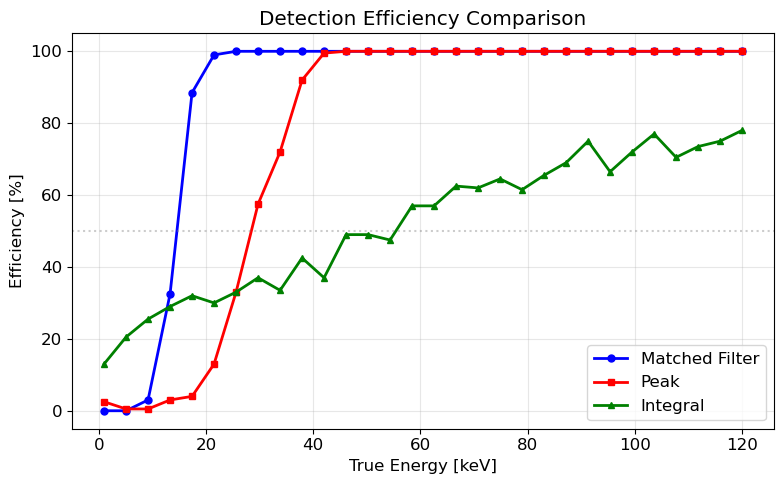

In [60]:
plt.figure(figsize=(8, 5))
plt.plot(E_inject, efficiency_mf*100, 'bo-', lw=2, ms=5, label='Matched Filter')
plt.plot(E_inject, efficiency_pk*100, 'rs-', lw=2, ms=5, label='Peak')
plt.plot(E_inject, efficiency_int*100, 'g^-', lw=2, ms=5, label='Integral')
plt.axhline(50, color='gray', ls=':', alpha=0.4)
plt.xlabel('True Energy [keV]'); plt.ylabel('Efficiency [%]')
plt.title('Detection Efficiency Comparison')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Final Comparison Table

In [61]:
print(f"{'Estimator':<18} {'sigE@25':<10} {'sigE@65':<10} {'sigE@100':<12} {'Thresh [keV]':<14}")
print("="*64)
print(f"{'Matched Filter':<18} {sigE_mf[0]:<10.2f} {sigE_mf[1]:<10.2f} {sigE_mf[2]:<12.2f} {E_thresh:<14.1f}")
print(f"{'Peak':<18} {sigE_pk[0]:<10.2f} {sigE_pk[1]:<10.2f} {sigE_pk[2]:<12.2f} {E_thresh_pk:<14.1f}")
print(f"{'Integral':<18} {sigE_int[0]:<10.2f} {sigE_int[1]:<10.2f} {sigE_int[2]:<12.2f} {E_thresh_int:<14.1f}")

Estimator          sigE@25    sigE@65    sigE@100     Thresh [keV]  
Matched Filter     6.45       9.75       11.86        14.4          
Peak               3.72       33.43      14.51        26.1          
Integral           3.32       54.18      2.32         39.4          


### Discussion

**Why does the matched filter beat the others?**

The matched filter uses both the known pulse shape AND the noise spectrum to weight each frequency optimally. Where the signal is strong and noise is weak, it cranks up the weight. Where noise dominates, it suppresses. This is the frequency-domain version of inverse-variance weighting from Problem 2.

The **peak estimator** just grabs the max sample. A single noise spike at any frequency can throw it off. It doesn't use the pulse shape at all.

The **integral estimator** sums everything in the pulse window. Better than one sample, but it treats all time bins equally and can't distinguish signal frequencies from noisy ones.

**How does colored noise matter?**

If noise were white (flat PSD), the matched filter still wins, but the gap is smaller. With colored noise, certain frequency bands are much noisier. The matched filter suppresses those bands. The other estimators can't, so they pick up extra noise from the loud frequencies.

Result: matched filter gives narrower peaks (better resolution), lower threshold, and higher detection efficiency at low energies.